In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from utils import neural_utils as nu
from mpl_toolkits import mplot3d

In [2]:
# boundary data (t,x)

N_b = 100

x_0 = torch.cat([torch.rand(50,1), torch.zeros(50,1)] , dim = 1)
x_1 = torch.cat([torch.rand(50,1), torch.ones(50,1)], dim = 1)

x_b = torch.cat([x_0,x_1], dim = 0)
u_b = torch.zeros(100,1)


# initial data

x_init = torch.cat([torch.zeros(50,1),torch.rand(50,1)], dim = 1)
u_init = torch.sin(torch.pi * x_init[:, 1:])



In [ ]:
# Sample collocation points
N_col = 1000
X_col = nu.sample(dim=2, N=N_col, domain_map=nu.identity_map, device='cpu')

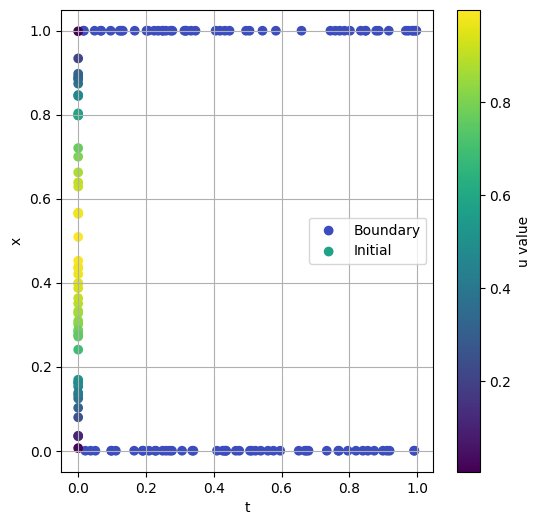

In [ ]:
# boundary points
t_b = x_b[:, 0].detach().numpy()
x_b_vals = x_b[:, 1].detach().numpy()

# initial points
t_init = x_init[:, 0].detach().numpy()
x_init_vals = x_init[:, 1].detach().numpy()

# collocation points
t_col = X_col[:, 0].detach().numpy()
x_col_vals = X_col[:, 1].detach().numpy()

plt.figure(figsize=(6,6))

plt.scatter(t_b, x_b_vals, c=u_b.numpy(), cmap='coolwarm', label="Boundary", s=50)
plt.scatter(t_init, x_init_vals, c=u_init.detach().numpy(), cmap='viridis', label="Initial", s=50)
plt.scatter(t_col, x_col_vals, c='red', alpha=0.3, label="Collocation", s=5)

plt.colorbar(label="u value")
plt.xlabel("t")
plt.ylabel("x")
plt.legend()
plt.grid()

plt.show()

In [ ]:
model = nu.FCN(2,1, 20,5)

model

FCN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): Tanh()
    (4): Linear(in_features=20, out_features=20, bias=True)
    (5): Tanh()
    (6): Linear(in_features=20, out_features=20, bias=True)
    (7): Tanh()
    (8): Linear(in_features=20, out_features=20, bias=True)
    (9): Tanh()
    (10): Linear(in_features=20, out_features=1, bias=True)
  )
)

In [ ]:
def make_heat_1d_residual(alpha):

    def residual_fn(X, u, grad_u):
        u_t = grad_u[:, 0:1]
        u_x = grad_u[:, 1:2]

        u_xx = nu.gradients(u_x, X)[:, 1:2]

        return u_t - alpha * u_xx

    return residual_fn

residual_fn = make_heat_1d_residual(0.1)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
X_data = torch.cat([x_b,x_init], dim = 0)
U_data = torch.cat([u_b, u_init], dim=0)

losses, losses_data, losses_phys, *_ = nu.train(30000, optimizer, X_data, U_data, model, residual_fn, 1, X_col)

0 0.29102858901023865 0.2910265624523163 2.0316683730925433e-06
100 0.1622496098279953 0.16203880310058594 0.00021080438455101103
200 0.11420924961566925 0.11248426139354706 0.0017249870579689741
300 0.1125171035528183 0.10929238796234131 0.0032247169874608517
400 0.11218269914388657 0.1088280901312828 0.003354608779773116
500 0.11180596798658371 0.10842254757881165 0.0033834187779575586
600 0.1113676205277443 0.10796737670898438 0.003400244750082493
700 0.11084050685167313 0.10743711143732071 0.0034033972769975662
800 0.1101655662059784 0.1067737340927124 0.00339182885363698
900 0.10920881479978561 0.10584510117769241 0.003363710595294833
1000 0.10767120867967606 0.1043628603219986 0.0033083485905081034
1100 0.10481412708759308 0.10162769258022308 0.003186433343216777
1200 0.09852786362171173 0.09564058482646942 0.0028872780967503786
1300 0.08330735564231873 0.08062797784805298 0.002679376630112529
1400 0.06444413214921951 0.05555598437786102 0.00888814963400364
1500 0.055898770689964

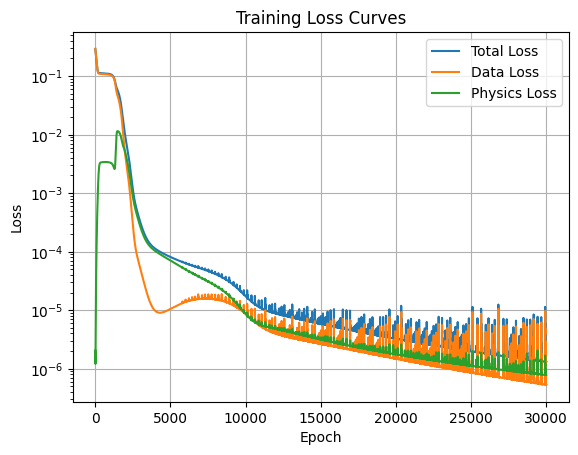

In [7]:
epochs = range(len(losses))

plt.plot(epochs, losses, label='Total Loss')
plt.plot(epochs, losses_data, label='Data Loss')
plt.plot(epochs, losses_phys, label='Physics Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training Loss Curves')

plt.yscale('log')
plt.legend()
plt.grid()

plt.show()

In [8]:
def analytic_solution(x,t):
    return torch.exp(-0.1 * torch.pi**2 * t) * torch.sin(torch.pi * x)

L2RE: 0.0008069911


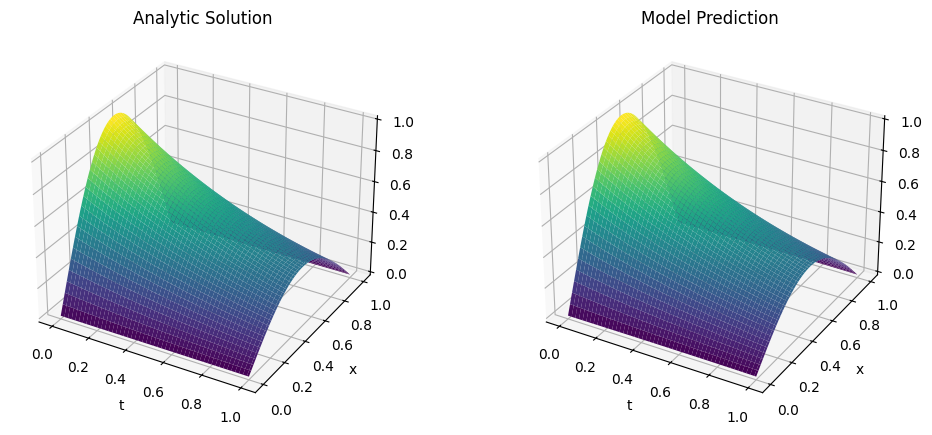

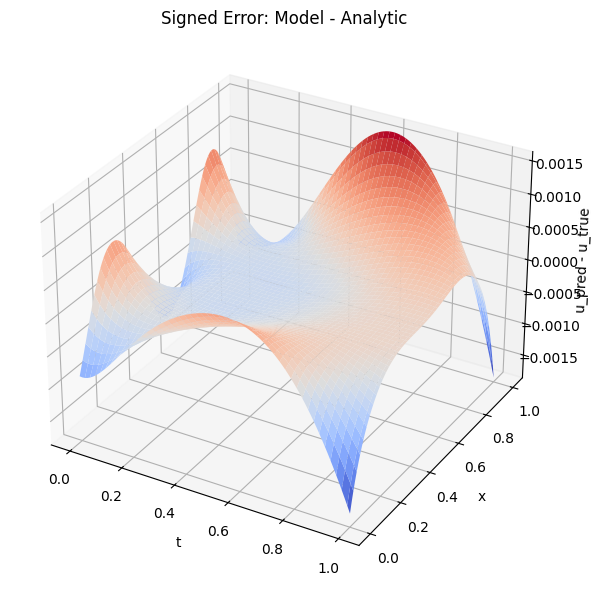

In [ ]:
# create mesh

N = 100

t = torch.linspace(0, 1, N)
x = torch.linspace(0, 1, N)

T, X = torch.meshgrid(t, x, indexing='ij')  # shape (N, N)

# flatten for model input
u_true = analytic_solution(X, T).detach()

model.eval()

data = torch.stack([T.reshape(-1), X.reshape(-1)], dim=1)
with torch.no_grad():
    u_pred = model(data).reshape(N, N)

print("L2RE:", nu.L2RE(u_pred,u_true))

u_true = u_true.cpu().numpy()
u_pred = u_pred.cpu().numpy()

T_np = T.numpy()
X_np = X.numpy()

fig = plt.figure(figsize=(14,5))
# --- analytic ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(T_np, X_np, u_true, cmap='viridis')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=15)
ax1.set_title("Analytic Solution")
ax1.set_xlabel("t")
ax1.set_ylabel("x")

# --- model ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(T_np, X_np, u_pred, cmap='viridis')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)
ax2.set_title("Model Prediction")
ax2.set_xlabel("t")
ax2.set_ylabel("x")
plt.show()


diff = u_pred - u_true

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

surf3 = ax.plot_surface(T_np, X_np, diff, cmap="coolwarm")
fig.colorbar(surf3, ax=ax, shrink=0.5, aspect=15)

ax.set_title("Signed Error: Model - Analytic")
ax.set_xlabel("t")
ax.set_ylabel("x")
ax.set_zlabel("u_pred - u_true")

plt.tight_layout()
plt.show()

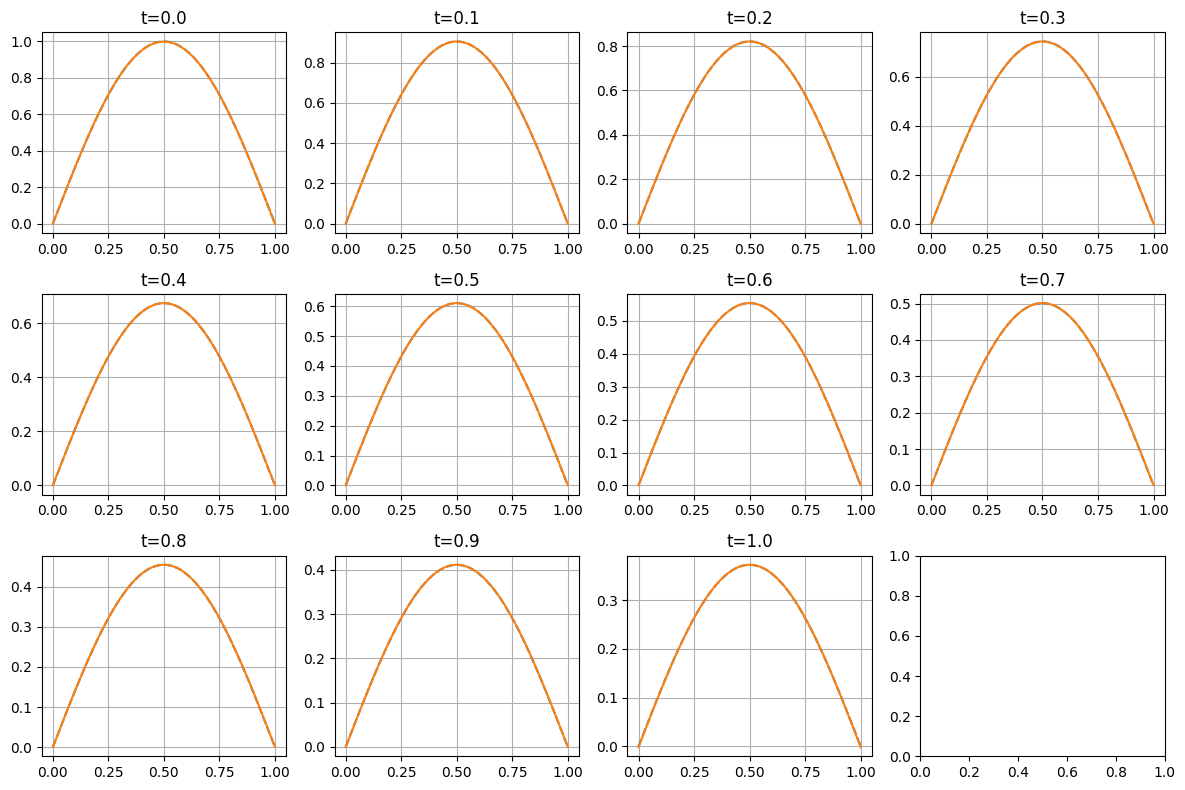

In [10]:
N_x = 200
x = torch.linspace(0, 1, N_x).reshape(-1,1)

t_slices = torch.linspace(0, 1, 11) 

model.eval()

fig, axes = plt.subplots(3, 4, figsize=(12,8))
axes = axes.flatten()

for i, t_val in enumerate(t_slices):
    ax = axes[i]

    t = torch.full_like(x, t_val)
    TX = torch.cat([t, x], dim=1)

    with torch.no_grad():
        u_pred = model(TX)

    u_true = analytic_solution(x, t).detach()

    ax.plot(x, u_true, '--', label='true')
    ax.plot(x, u_pred, '-', label='pred')

    ax.set_title(f"t={t_val:.1f}")
    ax.grid()

plt.tight_layout()
plt.show()

0 nan 0.21535710990428925 nan
100 nan 0.1319546103477478 nan
200 nan 0.11105208098888397 nan
300 nan 0.10120025277137756 nan
400 nan 0.08500418812036514 nan
500 nan 0.07573694735765457 nan
600 nan 0.07456528395414352 nan
700 nan 0.07362806797027588 nan
800 nan 0.0725221261382103 nan
900 nan 0.07115346193313599 nan
1000 nan 0.06939001381397247 nan
1100 nan 0.06705047935247421 nan
1200 nan 0.06389634311199188 nan
1300 nan 0.05961743742227554 nan
1400 nan 0.053814664483070374 nan
1500 nan 0.046002503484487534 nan
1600 nan 0.03564942255616188 nan
1700 nan 0.02264312654733658 nan
1800 nan 0.009985444135963917 nan
1900 nan 0.0038376383017748594 nan
2000 nan 0.002059156307950616 nan
2100 nan 0.00132179562933743 nan
2200 nan 0.0009297092910856009 nan
2300 nan 0.0006947281071916223 nan
2400 nan 0.0005426750285550952 nan
2500 nan 0.0004385228094179183 nan
2600 nan 0.00036374456249177456 nan
2700 nan 0.00030776573112234473 nan
2800 nan 0.00026422750670462847 nan
2900 nan 0.0002291683340445161 nan

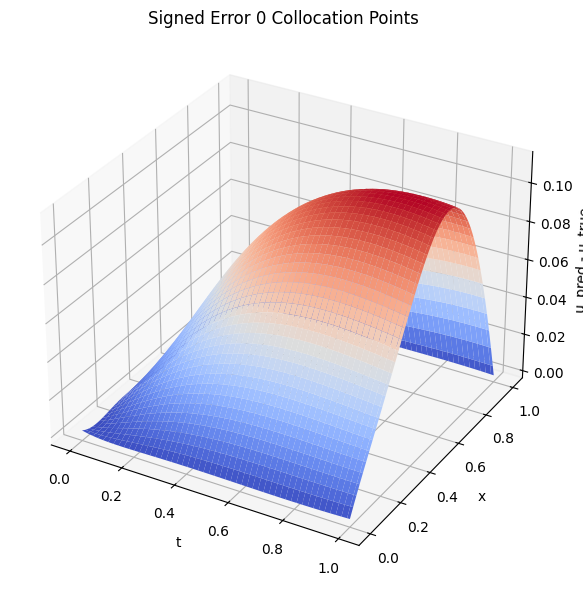

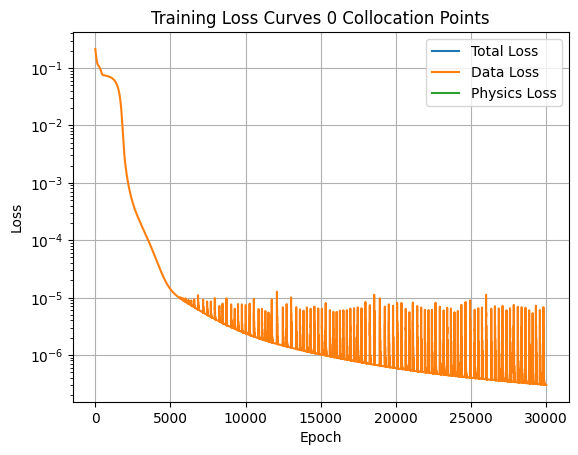

0 0.11656650900840759 0.11654617637395859 2.0332299754954875e-05
100 0.11279083788394928 0.10994668304920197 0.002844155766069889
200 0.11206085979938507 0.10865224152803421 0.0034086185041815042
300 0.11038268357515335 0.10654906928539276 0.003833616618067026
400 0.10360226780176163 0.09987292438745499 0.0037293422501534224
500 0.07044794410467148 0.06959822028875351 0.0008497221861034632
600 0.04789874330163002 0.047806791961193085 9.194966696668416e-05
700 0.03588477149605751 0.03574049472808838 0.0001442755456082523
800 0.018657078966498375 0.018554070964455605 0.00010300738358637318
900 0.003609305014833808 0.0035967854782938957 1.2519641131802928e-05
1000 0.000769778445828706 0.0007697659311816096 1.2536681914809833e-08
1100 0.00036858548992313445 0.0003685727424453944 1.2737694454756365e-08
1200 0.00022692531638313085 0.00022692352649755776 1.7833636789532648e-09
1300 0.00016508251428604126 0.00016507804684806615 4.46448567004154e-09
1400 0.0001307002385146916 0.0001306947815464

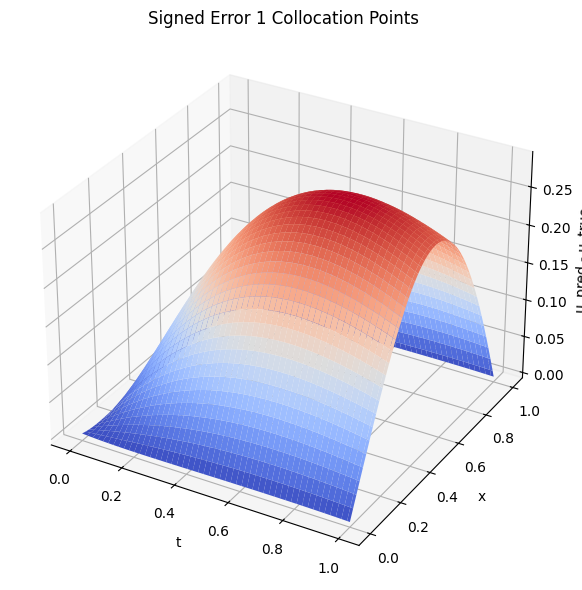

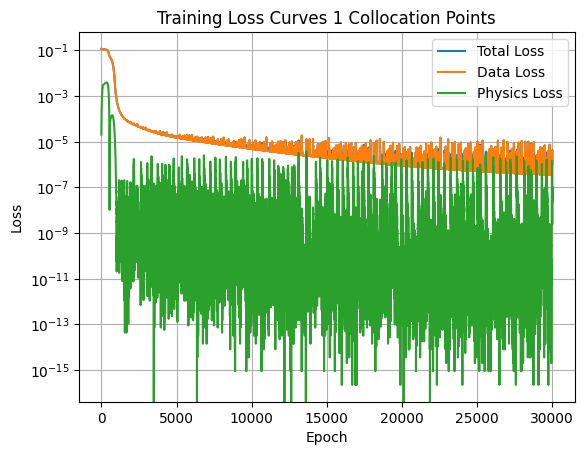

0 0.27292829751968384 0.27272406220436096 0.0002042283449554816
100 0.12858019769191742 0.1284632533788681 0.00011694315617205575
200 0.11332148313522339 0.11282478272914886 0.0004967036657035351
300 0.11154410988092422 0.10958997160196304 0.0019541392102837563
400 0.11074919998645782 0.10772247612476349 0.0030267240945249796
500 0.11002842336893082 0.1066313087940216 0.0033971169032156467
600 0.10916204750537872 0.105631023645401 0.0035310271196067333
700 0.10802016407251358 0.10441920906305313 0.0036009568721055984
800 0.10636734962463379 0.10274486988782883 0.0036224767100065947
900 0.10371087491512299 0.10013977438211441 0.0035710984375327826
1000 0.09891218692064285 0.0955425426363945 0.0033696461468935013
1100 0.08911377936601639 0.0862501859664917 0.0028635954950004816
1200 0.06821925938129425 0.06607083976268768 0.002148417290300131
1300 0.03733016550540924 0.033921532332897186 0.0034086343366652727
1400 0.02080044336616993 0.01618337072432041 0.004617073107510805
1500 0.013553

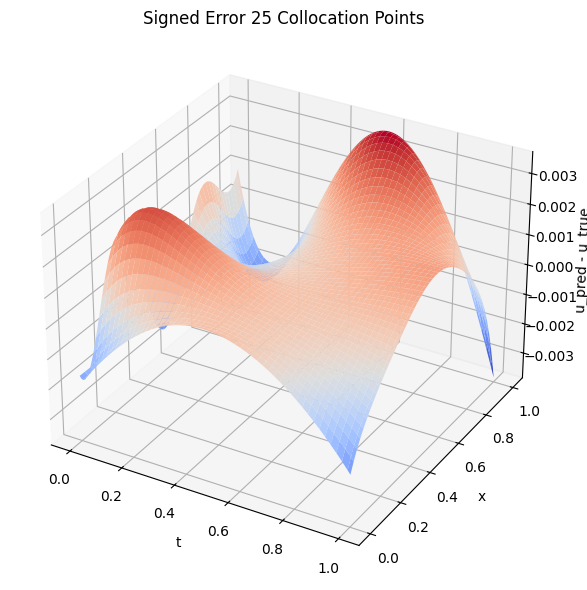

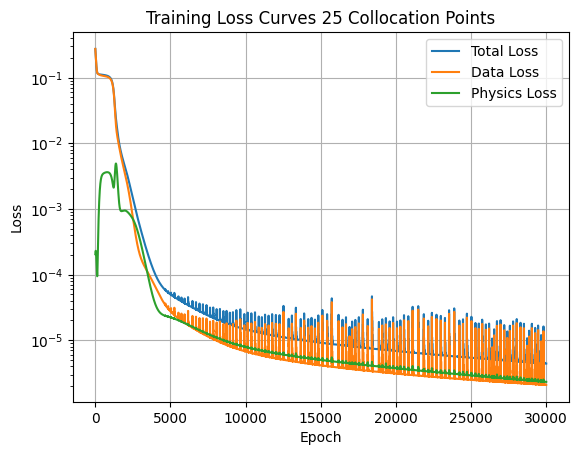

0 0.12108639627695084 0.12098691612482071 9.94807414826937e-05
100 0.11279318481683731 0.11120772361755371 0.0015854648081585765
200 0.11193592846393585 0.10800793766975403 0.003927987068891525
300 0.11144382506608963 0.10745234042406082 0.003991485107690096
400 0.11036472767591476 0.10632508248090744 0.004039647988975048
500 0.10648086667060852 0.10258816927671432 0.003892694367095828
600 0.08534173667430878 0.0823625847697258 0.0029791512060910463
700 0.028130900114774704 0.023783205077052116 0.004347695503383875
800 0.010334690101444721 0.007426114287227392 0.0029085755813866854
900 0.006571430712938309 0.004238040652126074 0.002333390060812235
1000 0.005081885494291782 0.0028352627996355295 0.002246622461825609
1100 0.0038700024597346783 0.0019453251734375954 0.001924677169881761
1200 0.0027816505171358585 0.001264676102437079 0.0015169745311141014
1300 0.0018680650973692536 0.0007645313162356615 0.0011035337811335921
1400 0.0011913832277059555 0.0004333218384999782 0.0007580614183

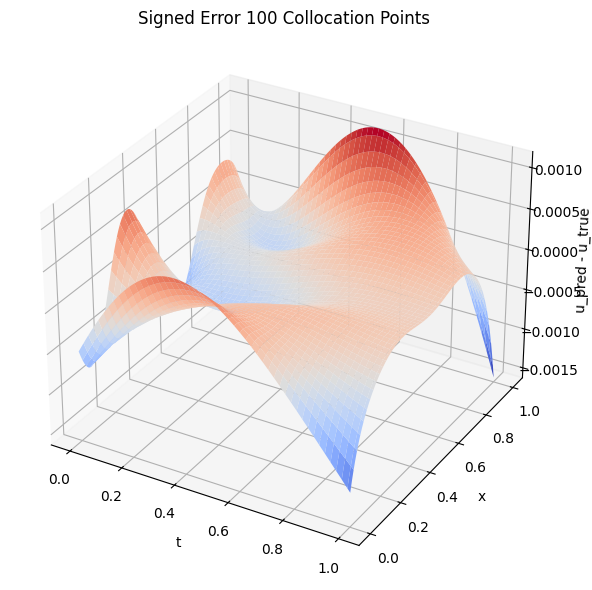

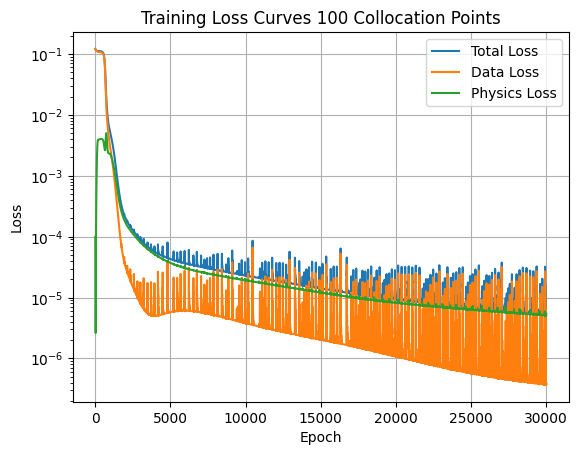

0 0.11900138109922409 0.11885063350200653 0.00015074966358952224
100 0.11229395866394043 0.10929480195045471 0.002999156014993787
200 0.11156538873910904 0.10766508430242538 0.003900303738191724
300 0.11013399064540863 0.10617543756961823 0.003958552610129118
400 0.10481903702020645 0.10111604630947113 0.003702988848090172
500 0.0793059691786766 0.07648850232362747 0.0028174687176942825
600 0.028400816023349762 0.02250262349843979 0.005898193456232548
700 0.01530936174094677 0.01186936255544424 0.003439998719841242
800 0.010858356021344662 0.008730744943022728 0.00212761084549129
900 0.008122934028506279 0.00640098424628377 0.0017219497822225094
1000 0.006139025092124939 0.004601678811013699 0.001537346513941884
1100 0.0045294566079974174 0.0032050576992332935 0.0013243986759334803
1200 0.003122026100754738 0.0020720052998512983 0.0010500209173187613
1300 0.001988061238080263 0.0012115569552406669 0.0007765042828395963
1400 0.001189450384117663 0.0006443579331971705 0.00054509245092049

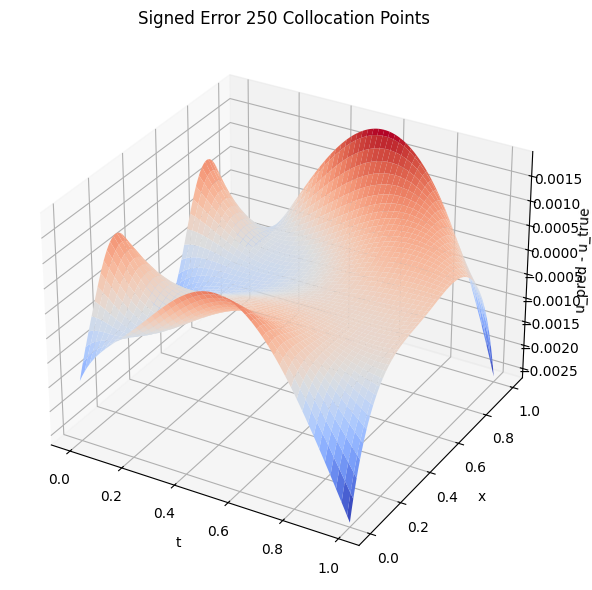

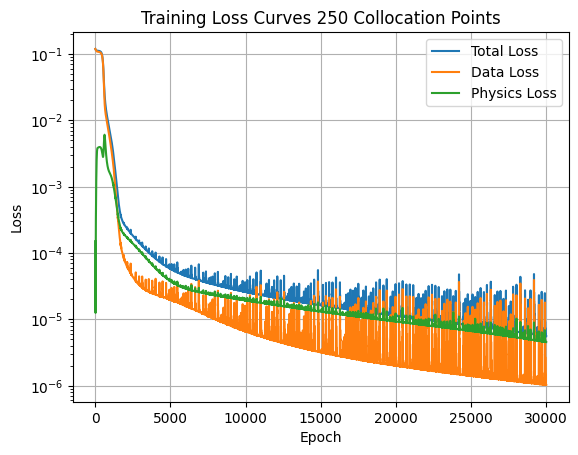

0 0.11940596997737885 0.11915586143732071 0.0002501103444956243
100 0.11263804882764816 0.11053026467561722 0.0021077836863696575
200 0.1114364042878151 0.10746752470731735 0.003968877252191305
300 0.10924014449119568 0.10515914112329483 0.00408100476488471
400 0.09941107034683228 0.0957823097705841 0.0036287636030465364
500 0.056248217821121216 0.054080020636320114 0.0021681981161236763
600 0.01177508756518364 0.009490087628364563 0.0022849994711577892
700 0.006781863979995251 0.005274644121527672 0.0015072199748829007
800 0.005233257543295622 0.00349812232889235 0.0017351350979879498
900 0.004274825565516949 0.0025082877837121487 0.0017665380146354437
1000 0.0035088141448795795 0.0018580671167001128 0.001650746911764145
1100 0.0028370521031320095 0.0013554487377405167 0.001481603248976171
1200 0.002261511515825987 0.0009858290432021022 0.0012756824726238847
1300 0.0017471128376200795 0.0007133886683732271 0.0010337241692468524
1400 0.0013093609595671296 0.0005054192733950913 0.000803

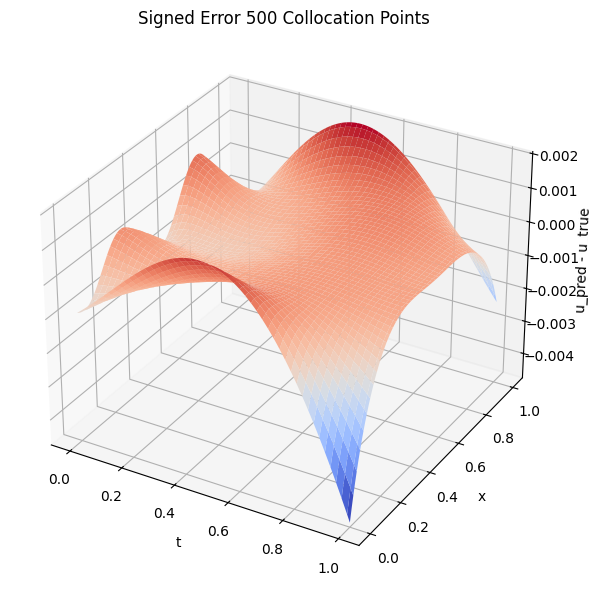

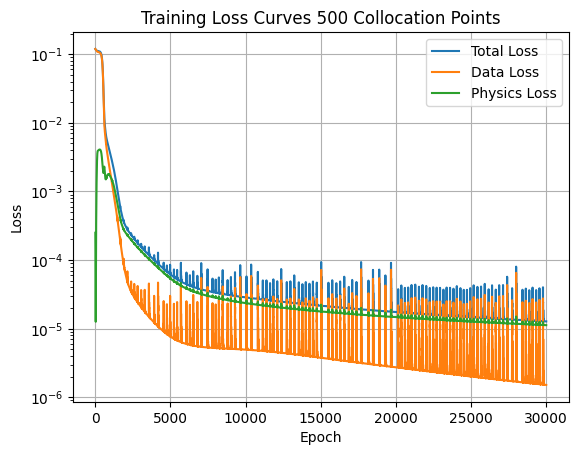

0 0.2248603254556656 0.22485244274139404 7.88662873674184e-06
100 0.11875403672456741 0.11864901334047318 0.00010502679651835933
200 0.11276861280202866 0.11063091456890106 0.0021377005614340305
300 0.11220431327819824 0.10866384208202362 0.003540472825989127
400 0.11180007457733154 0.10813551396131516 0.0036645601503551006
500 0.11128361523151398 0.1075989305973053 0.0036846876610070467
600 0.1105639711022377 0.10686834901571274 0.003695620922371745
700 0.10944415628910065 0.1057519018650055 0.0036922572180628777
800 0.10743462294340134 0.10378165543079376 0.0036529693752527237
900 0.10315629839897156 0.0996517688035965 0.0035045272670686245
1000 0.09269368648529053 0.08955437690019608 0.0031393091194331646
1100 0.06977059692144394 0.06595661491155624 0.0038139817770570517
1200 0.04418273642659187 0.03662656620144844 0.00755617069080472
1300 0.023650867864489555 0.017909862101078033 0.005741005297750235
1400 0.011396314948797226 0.007743884809315205 0.0036524306051433086
1500 0.007009

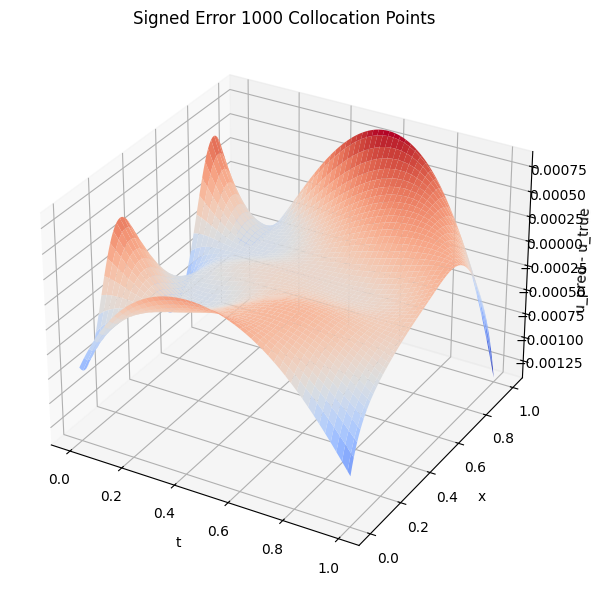

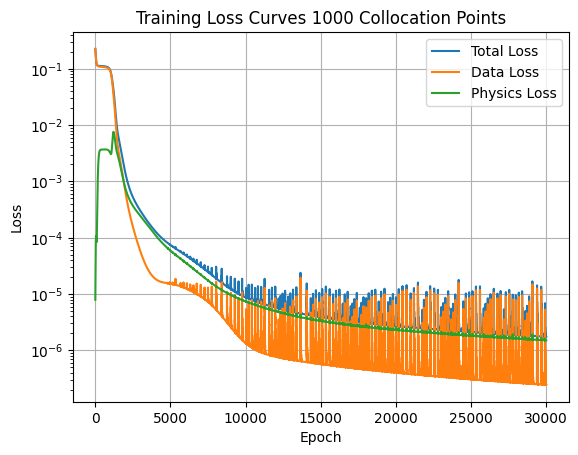

0 0.12160440534353256 0.12159403413534164 1.03678894447512e-05
100 0.11449643224477768 0.1139601543545723 0.000536278064828366
200 0.11212895065546036 0.10890739411115646 0.003221557242795825
300 0.11105722934007645 0.1072445958852768 0.003812631592154503
400 0.10935786366462708 0.10532348603010178 0.004034380428493023
500 0.10497995465993881 0.1007881835103035 0.004191773943603039
600 0.08776881545782089 0.08290261775255203 0.004866194911301136
700 0.047392766922712326 0.03830057755112648 0.009092189371585846
800 0.013804333284497261 0.010118112899363041 0.0036862206179648638
900 0.005981225520372391 0.004542920272797346 0.0014383054804056883
1000 0.004044952802360058 0.002914455020800233 0.0011304980143904686
1100 0.002777895424515009 0.0018648746190592647 0.0009130209218710661
1200 0.001859803218394518 0.0011270493268966675 0.0007327538332901895
1300 0.0012270056176930666 0.0006485210615210235 0.000578484614379704
1400 0.0008245976059697568 0.0003691914607770741 0.000455406145192682

In [ ]:
# test collocation points

test = [0, 1, 25, 100, 250, 500, 1000, 5000, 10000]
results = []

seed = 0

torch.manual_seed(seed)
np.random.seed(seed)

u_true = analytic_solution(X, T).detach().cpu().numpy()

for n in test:
    
    test_model = nu.FCN(2,1, 20,5)
    optimizer = torch.optim.Adam(test_model.parameters(), lr=1e-4)
    losses, losses_data, losses_phys, *_= nu.train(
        30000, optimizer, X_data, U_data, test_model,
        residual_fn, 1, 2, n
    )

    final_loss = losses[0]

    results.append(final_loss)

    test_model.eval()

    # plot error surface

    data = torch.stack([T.reshape(-1), X.reshape(-1)], dim=1)
    with torch.no_grad():
        u_pred = test_model(data).reshape(N, N).cpu().numpy()
    print(u_pred.shape)
    print(u_true.shape)
    diff = u_pred - u_true

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(T_np, X_np, diff, cmap="coolwarm")
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=15)

    ax.set_title(f"Signed Error {n} Collocation Points")
    ax.set_xlabel("t")
    ax.set_ylabel("x")
    ax.set_zlabel("u_pred - u_true")

    plt.tight_layout()
    plt.show()

    # training curves

    epochs = range(len(losses))

    plt.plot(epochs, losses, label='Total Loss')
    plt.plot(epochs, losses_data, label='Data Loss')
    plt.plot(epochs, losses_phys, label='Physics Loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training Loss Curves {n} Collocation Points')

    plt.yscale('log')
    plt.legend()
    plt.grid()

    plt.show()
    
plt.plot(test, results)
plt.xlabel('Collocation Points per Step')
plt.ylabel('Final Loss')
plt.title('Final Loss 30000 Epochs')
plt.show()